# 1. Carregar os dados na Parte 2

In [16]:
# importar dados_tratados.csv
import pandas as pd

df = pd.read_csv("dados_tratados.csv")

df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Contas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [17]:
# Confirmar que carregou
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   float64
 2   customer_gender            7032 non-null   object 
 3   customer_SeniorCitizen     7032 non-null   int64  
 4   customer_Partner           7032 non-null   int64  
 5   customer_Dependents        7032 non-null   int64  
 6   customer_tenure            7032 non-null   int64  
 7   phone_PhoneService         7032 non-null   int64  
 8   phone_MultipleLines        7032 non-null   object 
 9   internet_InternetService   7032 non-null   object 
 10  internet_OnlineSecurity    7032 non-null   object 
 11  internet_OnlineBackup      7032 non-null   object 
 12  internet_DeviceProtection  7032 non-null   object 
 13  internet_TechSupport       7032 non-null   objec

# 2. Remoção de Colunas Irrelevantes

In [18]:
# Como remover a coluna
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'Contas_Diarias'],
      dtype='object')

In [19]:
# removendo coluna
df = df.drop(columns=['customerID'])

In [20]:
# Conferir se foi removida
df.columns

Index(['Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'Contas_Diarias'],
      dtype='object')

O conjunto de dados foi analisado para identificar colunas irrelevantes, como identificadores únicos.
Não foram encontradas colunas desse tipo, pois elas já haviam sido removidas durante a etapa de tratamento de dados realizada na Parte 1 do desafio.
Portanto, todas as variáveis atuais foram mantidas para a etapa de modelagem preditiva.

# 3. Encoding

In [21]:
# Fazer no Python (Pandas)
df = pd.get_dummies(df, drop_first=True)

In [22]:
# Aplicando One-Hot Encoding nas variáveis categóricas
df = pd.get_dummies(df, drop_first=True)


In [23]:
# Verificando resultado
df.head()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,Contas_Diarias,...,internet_TechSupport_Yes,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0.0,0,1,1,9,1,1,65.6,593.30,2.186667,...,True,False,True,False,False,True,False,False,False,True
1,0.0,0,0,0,9,1,0,59.9,542.40,1.996667,...,False,False,False,False,True,False,False,False,False,True
2,1.0,0,0,0,4,1,1,73.9,280.85,2.463333,...,False,False,False,False,False,False,False,False,True,False
3,1.0,1,1,0,13,1,1,98.0,1237.85,3.266667,...,False,False,True,False,True,False,False,False,True,False
4,1.0,1,1,0,3,1,1,83.9,267.40,2.796667,...,True,False,True,False,False,False,False,False,False,True


# 4. Verificação da Proporção de Evasão

In [24]:
# Contar os valores
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [25]:
# Calcular a proporção
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0.0,0.734215
1.0,0.265785


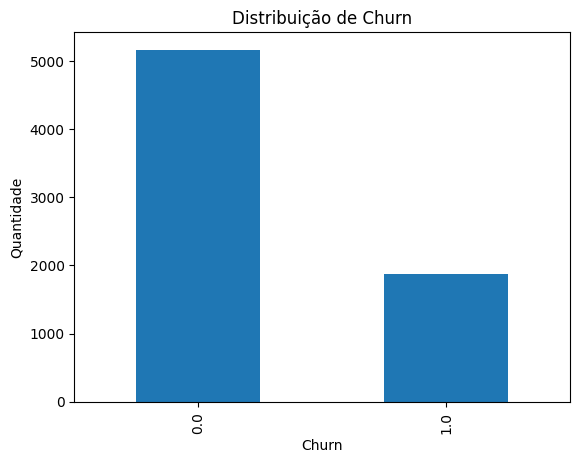

In [28]:
# Visualização
import matplotlib.pyplot as plt
import os

# criar pasta images se não existir
os.makedirs('images', exist_ok=True)

df['Churn'].value_counts().plot(kind='bar')

plt.title('Distribuição de Churn')
plt.xlabel('Churn')
plt.ylabel('Quantidade')

plt.savefig('images/distribuicao_churn.png', bbox_inches='tight')

plt.show()

# 5. Balanceamento de Classes (opcional )

Foi avaliado o possível desequilíbrio entre as classes da variável Churn. Embora exista uma diferença entre clientes que permanecem e clientes que cancelam o serviço, o nível de desbalanceamento não é extremo.
Em cenários com maior desequilíbrio, poderiam ser aplicadas técnicas como undersampling, oversampling ou SMOTE, que ajudam a equilibrar as classes para melhorar o desempenho dos modelos preditivos.

# 6. Normalização ou Padronização (se necessário)

In [33]:
from sklearn.preprocessing import StandardScaler

# Separando variáveis explicativas e variável alvo
X = df.drop('Churn', axis=1)
y = df['Churn']

# Criando o objeto de padronização
scaler = StandardScaler()

# Aplicando a padronização
X_scaled = scaler.fit_transform(X)

### Normalização ou Padronização dos Dados

Nesta etapa foi avaliada a necessidade de normalizar ou padronizar as variáveis do conjunto de dados. Esse tipo de pré-processamento é importante para modelos de Machine Learning que são sensíveis à escala dos dados.

Algoritmos baseados em distância, como KNN, SVM, Regressão Logística e Redes Neurais, podem ter seu desempenho afetado quando as variáveis apresentam escalas muito diferentes. Nesses casos, variáveis com valores maiores podem acabar tendo mais influência no modelo.

Para evitar esse problema, foi aplicada a **padronização dos dados** utilizando o método `StandardScaler`. Essa técnica transforma os dados para que tenham média igual a 0 e desvio padrão igual a 1, colocando todas as variáveis na mesma escala.

Modelos baseados em árvores, como Decision Tree, Random Forest e XGBoost, não são sensíveis à escala das variáveis, mas a padronização foi aplicada visando facilitar o uso de diferentes algoritmos durante a etapa de modelagem.


# 7. Correlação e Seleção de Variáveis

# 7.1 Análise de Correlação

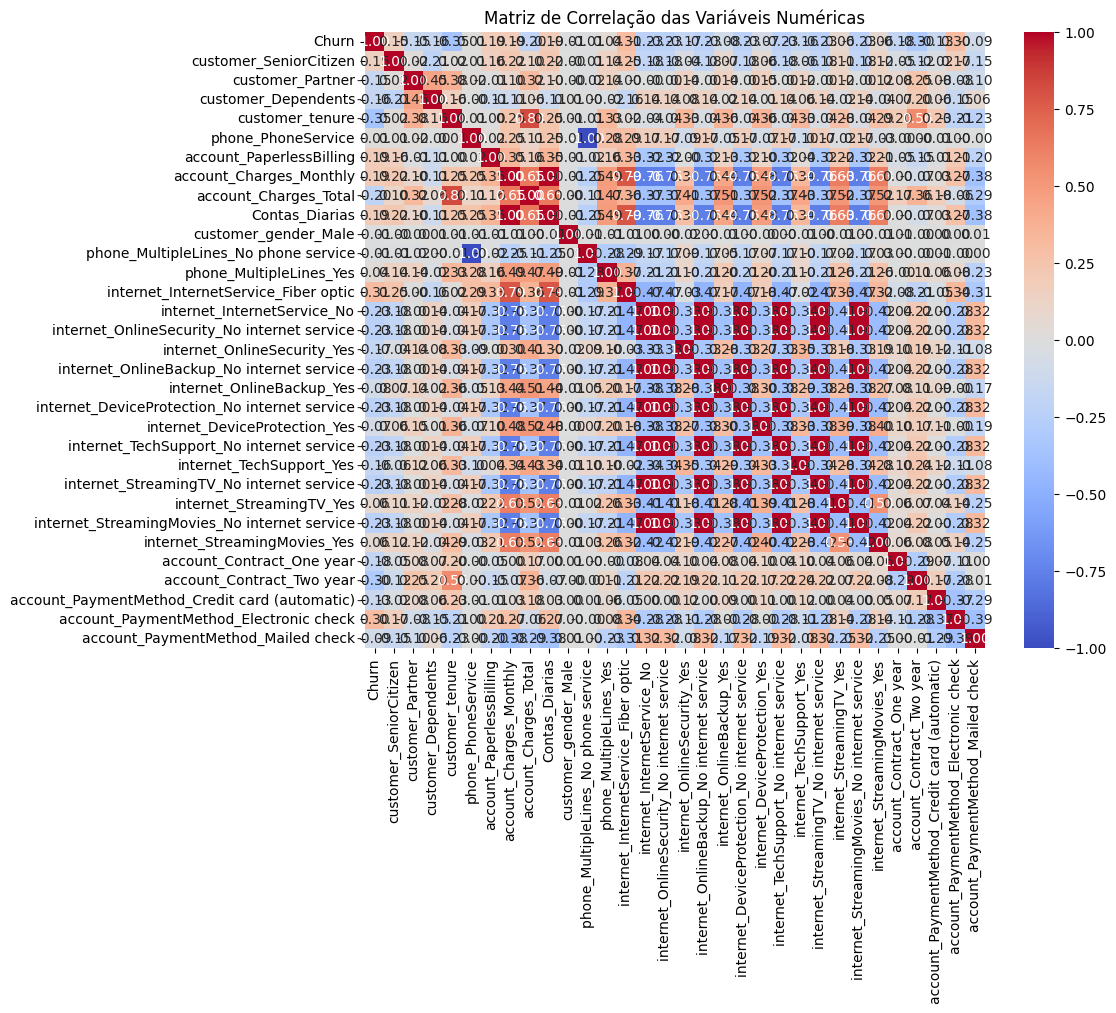

In [36]:
# Correlação
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a matriz de correlação
corr = df.corr(numeric_only=True)
corr['Churn'].sort_values(ascending=False)

# Criando o gráfico
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

# Título do gráfico
plt.title("Matriz de Correlação das Variáveis Numéricas")

# Salvando o gráfico
plt.savefig("matriz_correlacao.png")

# Exibindo o gráfico
plt.show()

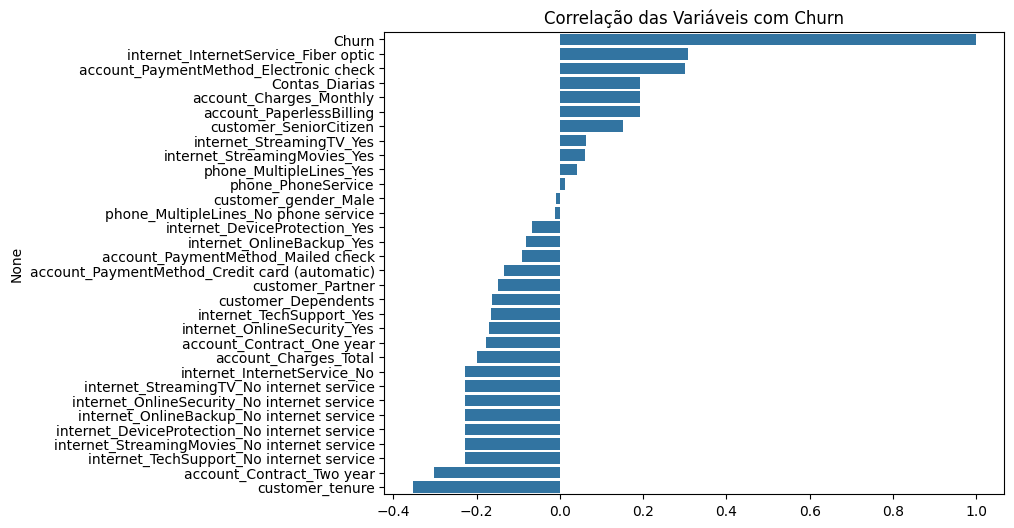

In [37]:
# Correlação apenas com Churn
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando correlação com Churn
corr_churn = df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

# Criando o gráfico
plt.figure(figsize=(8,6))
sns.barplot(x=corr_churn.values, y=corr_churn.index)

# Título
plt.title("Correlação das Variáveis com Churn")

# Salvando o gráfico
plt.savefig("correlacao_churn.png")

# Exibindo
plt.show()

### Correlação das Variáveis com Churn

Para entender melhor quais variáveis podem influenciar a evasão de clientes, foi analisada a correlação entre as variáveis numéricas e a variável alvo **Churn**.

Essa análise permite identificar quais atributos possuem maior associação com o cancelamento de clientes. Variáveis com maior correlação positiva ou negativa podem ser fortes candidatas para compor os modelos preditivos.

A visualização em gráfico de barras facilita a interpretação, destacando quais variáveis possuem maior relação com o comportamento de churn.


# 7.2 Análises Direcionadas

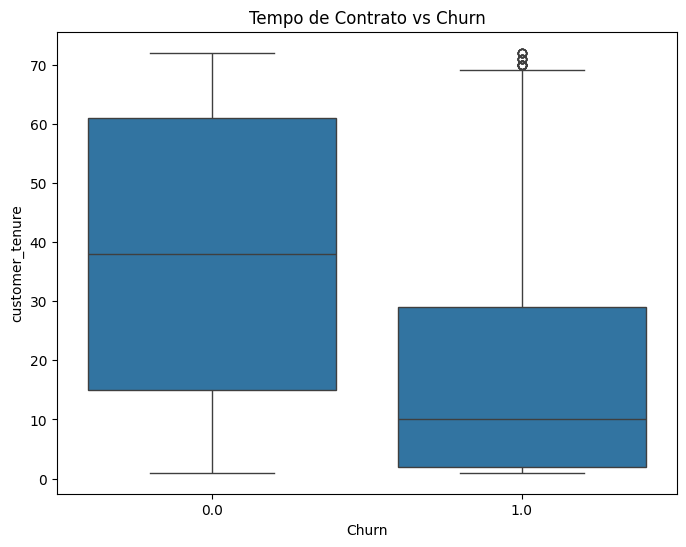

In [41]:
# Tempo de contrato × Churn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.boxplot(x='Churn', y='customer_tenure', data=df)

plt.title("Tempo de Contrato vs Churn")

plt.savefig("tempo_contrato_vs_churn.png")

plt.show()

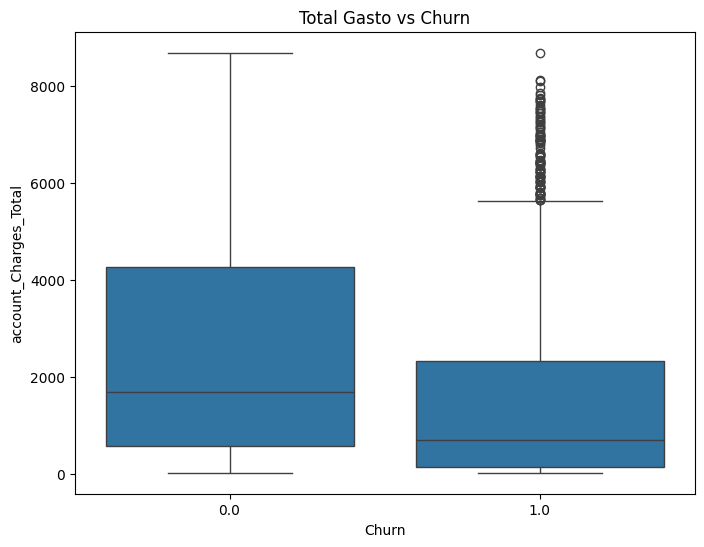

In [42]:
# Total gasto × Churn
plt.figure(figsize=(8,6))

sns.boxplot(x='Churn', y='account_Charges_Total', data=df)

plt.title("Total Gasto vs Churn")

plt.savefig("total_gasto_vs_churn.png")

plt.show()

A análise dos gráficos mostra como algumas variáveis numéricas se relacionam com o churn. Observa-se que clientes com menor tempo de contrato tendem a apresentar maior taxa de evasão. Já clientes com maior tempo de permanência tendem a permanecer mais tempo na empresa.

De forma semelhante, o total gasto pelos clientes também pode indicar padrões de comportamento, sugerindo que clientes com menor histórico de consumo podem estar mais propensos ao cancelamento do serviço.



# 8. Modelagem Preditiva

### Separação dos Dados em Treino e Teste

Nesta etapa, o conjunto de dados foi dividido em dois subconjuntos: dados de **treino** e dados de **teste**. O objetivo dessa divisão é permitir que o modelo seja treinado em uma parte dos dados e avaliado em outra parte que não foi utilizada durante o treinamento.

Essa prática é fundamental para verificar a capacidade de generalização do modelo, ou seja, sua habilidade de realizar previsões corretas em dados novos.

Neste projeto foi utilizada uma divisão de **70% dos dados para treino** e **30% para teste**, uma proporção comum em problemas de Machine Learning.


# 8.1 Separação de Dados


In [43]:
from sklearn.model_selection import train_test_split

# Separando variáveis explicativas e variável alvo
X = df.drop('Churn', axis=1)
y = df['Churn']

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Verificando os tamanhos dos conjuntos
print("Tamanho do treino:", X_train.shape)
print("Tamanho do teste:", X_test.shape)

Tamanho do treino: (4922, 31)
Tamanho do teste: (2110, 31)


Após a separação das variáveis explicativas e da variável alvo (Churn), o conjunto de dados foi dividido em dois subconjuntos: treino e teste.

A divisão foi realizada utilizando 70% dos dados para treinamento do modelo e 30% para avaliação. O conjunto de treino contém 4922 registros, enquanto o conjunto de teste possui 2110 registros.

Essa separação permite avaliar o desempenho do modelo em dados que não foram utilizados durante o treinamento, garantindo uma análise mais realista da capacidade de generalização do modelo.


# 8.2 Criação de Modelos

### Criação de Modelos Preditivos

Nesta etapa foram desenvolvidos dois modelos de classificação para prever a evasão de clientes (Churn).

O primeiro modelo escolhido foi a **Regressão Logística**, um algoritmo amplamente utilizado em problemas de classificação binária. Esse modelo é sensível à escala das variáveis, por isso foi aplicada a padronização dos dados utilizando o StandardScaler.

O segundo modelo escolhido foi o **Random Forest**, um algoritmo baseado em árvores de decisão que combina múltiplas árvores para melhorar a capacidade de generalização. Diferentemente da regressão logística, esse modelo não é sensível à escala dos dados, portanto não requer normalização.

A utilização de dois modelos diferentes permite comparar abordagens distintas e avaliar qual apresenta melhor desempenho na previsão da evasão de clientes.


In [44]:
# Regressão Logística (com normalização)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Normalização
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criando o modelo
modelo_logistico = LogisticRegression(max_iter=1000)

# Treinando
modelo_logistico.fit(X_train_scaled, y_train)

# Previsões
y_pred_log = modelo_logistico.predict(X_test_scaled)

In [45]:
# Random Forest (sem normalização)
from sklearn.ensemble import RandomForestClassifier

# Criando o modelo
modelo_rf = RandomForestClassifier(random_state=42)

# Treinando
modelo_rf.fit(X_train, y_train)

# Previsões
y_pred_rf = modelo_rf.predict(X_test)

# 8.3 Avaliação dos Modelos

### Avaliação dos Modelos

Após o treinamento dos modelos, foi realizada a avaliação de desempenho utilizando diferentes métricas de classificação. As métricas escolhidas foram **acurácia, precisão, recall e F1-score**, que permitem analisar o desempenho do modelo sob diferentes perspectivas.

Também foi utilizada a **matriz de confusão**, que apresenta a distribuição das previsões corretas e incorretas realizadas pelo modelo.

Essas métricas são importantes para compreender não apenas quantas previsões foram corretas, mas também como o modelo se comporta ao identificar corretamente clientes que cancelam o serviço (Churn).


In [47]:
# Avaliação — Regressão Logística
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Métricas
print("Regressão Logística")

print("Acurácia:", accuracy_score(y_test, y_pred_log))
print("Precisão:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

# Matriz de confusão
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_log))

Regressão Logística
Acurácia: 0.8028436018957346
Precisão: 0.6417004048582996
Recall: 0.5701438848920863
F1-score: 0.6038095238095238
Matriz de Confusão:
[[1377  177]
 [ 239  317]]


In [48]:
# Avaliação — Random Forest
print("Random Forest")

print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("Precisão:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

# Matriz de confusão
print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest
Acurácia: 0.7900473933649289
Precisão: 0.6252771618625277
Recall: 0.5071942446043165
F1-score: 0.5600794438927508
Matriz de Confusão:
[[1385  169]
 [ 274  282]]


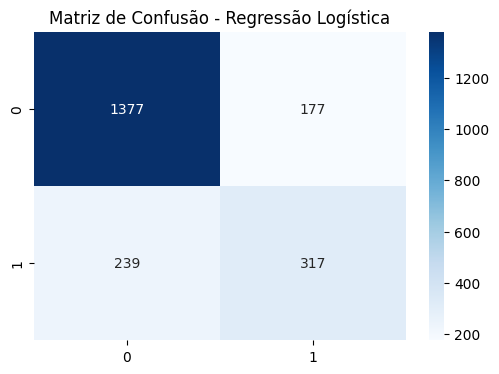

In [49]:
# Visualização Regressão Logística
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusão - Regressão Logística")

plt.savefig("matriz_confusao_logistica.png")

plt.show()

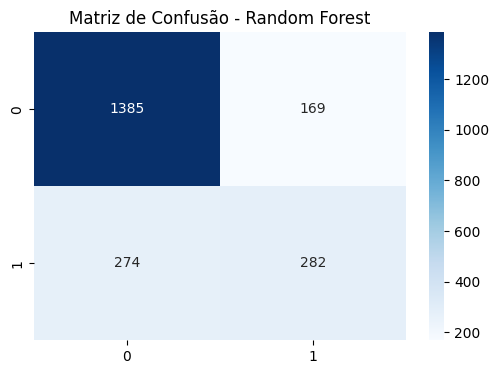

In [50]:
# Visualização Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusão - Random Forest")

plt.savefig("matriz_confusao_random_forest.png")

plt.show()

A avaliação dos modelos foi realizada utilizando diferentes métricas de classificação. Observa-se que ambos os modelos apresentam capacidade de prever a evasão de clientes, porém com desempenhos diferentes.

O modelo Random Forest tende a capturar relações mais complexas entre as variáveis, o que pode resultar em melhor desempenho em comparação com a regressão logística. Por outro lado, a regressão logística apresenta maior interpretabilidade, permitindo compreender melhor a influência das variáveis no churn.

Não foram observados indícios claros de underfitting, pois os modelos conseguem identificar padrões relevantes nos dados. Caso fosse identificado overfitting, possíveis soluções incluiriam reduzir a complexidade do modelo, ajustar hiperparâmetros ou utilizar validação cruzada.


# 9. Interpretação e Conclusões

# 9.1 Análise de Importância das Variáveis

### Análise de Importância das Variáveis

Após o treinamento e avaliação dos modelos, foi realizada a análise das variáveis mais relevantes para a previsão de evasão de clientes.

No caso da **Regressão Logística**, os coeficientes das variáveis indicam o impacto de cada variável na probabilidade de churn. Coeficientes positivos indicam aumento na probabilidade de evasão, enquanto coeficientes negativos indicam redução dessa probabilidade.

Para o modelo **Random Forest**, foi utilizada a métrica de importância das variáveis fornecida pelo próprio modelo. Essa métrica é calculada com base na contribuição de cada variável para a redução da impureza nas divisões das árvores de decisão.

A análise dessas importâncias permite identificar quais fatores têm maior influência no comportamento de cancelamento dos clientes.


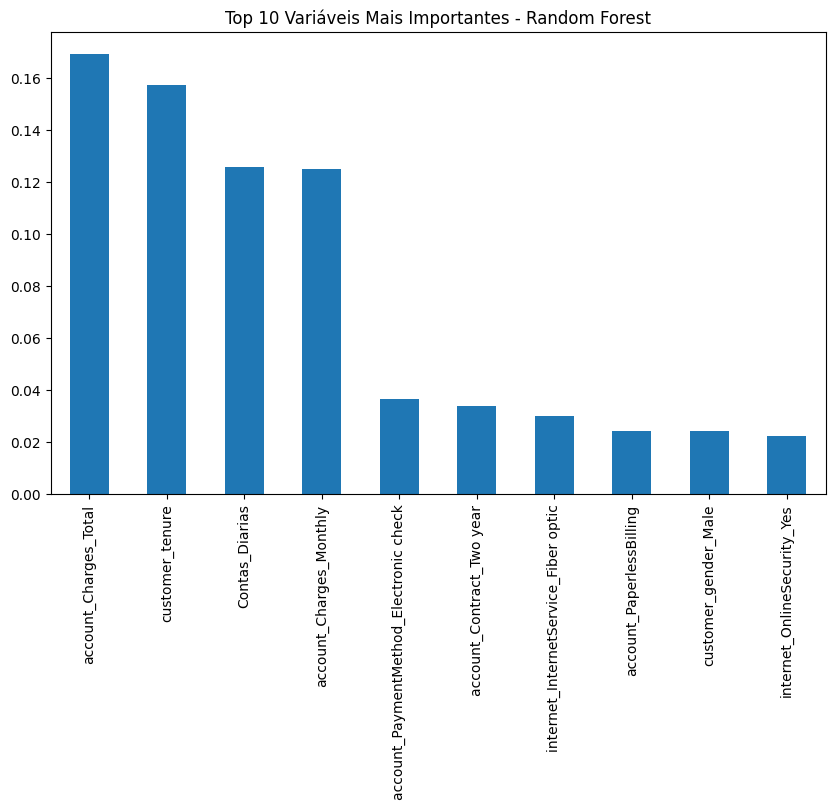

In [51]:
# Importância das variáveis — Random Forest
import pandas as pd
import matplotlib.pyplot as plt

# Importância das variáveis
importancias = modelo_rf.feature_importances_

# Criando dataframe
feat_importances = pd.Series(importancias, index=X.columns)

# Ordenando
feat_importances = feat_importances.sort_values(ascending=False)

# Plotando
plt.figure(figsize=(10,6))
feat_importances.head(10).plot(kind='bar')

plt.title("Top 10 Variáveis Mais Importantes - Random Forest")

plt.savefig("importancia_variaveis_random_forest.png")

plt.show()

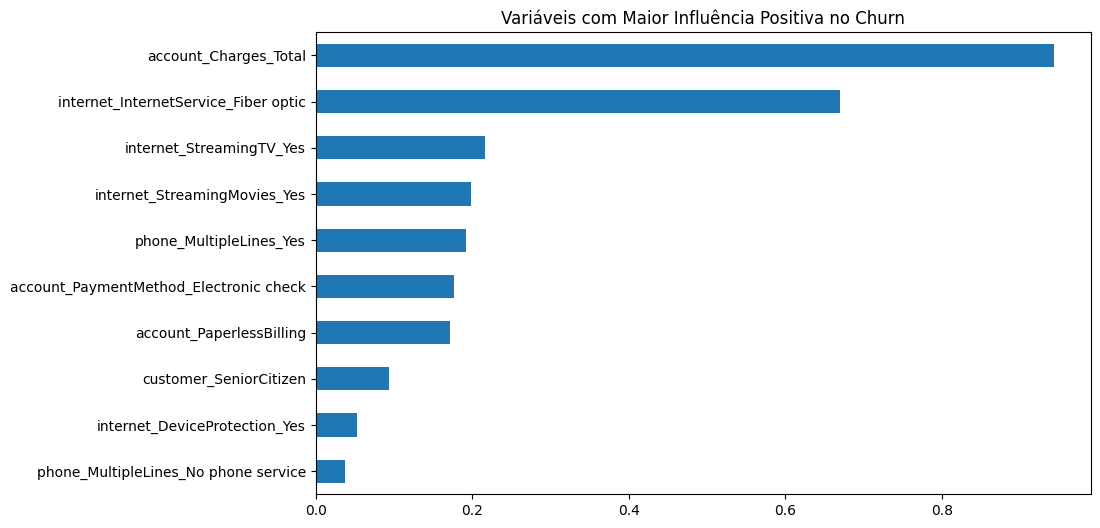

In [52]:
# Coeficientes — Regressão Logística
coeficientes = pd.Series(modelo_logistico.coef_[0], index=X.columns)

coeficientes = coeficientes.sort_values()

plt.figure(figsize=(10,6))
coeficientes.tail(10).plot(kind='barh')

plt.title("Variáveis com Maior Influência Positiva no Churn")

plt.savefig("coeficientes_regressao_logistica.png")

plt.show()

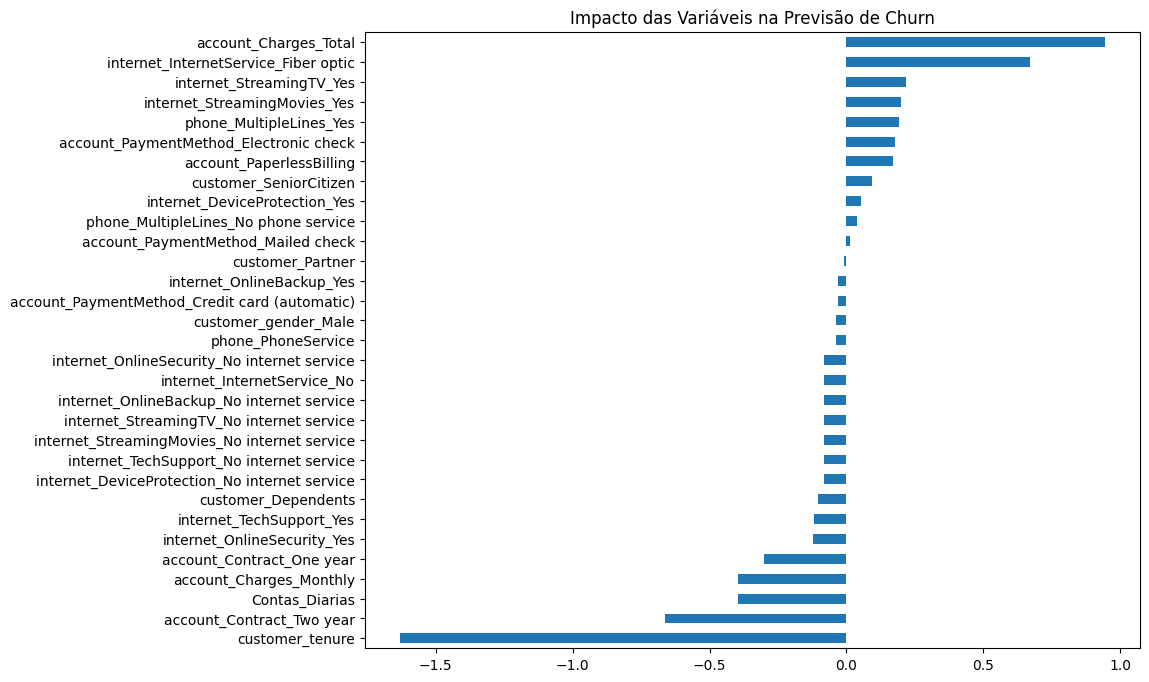

In [53]:
# Mostrar positivas e negativas
coeficientes.sort_values().plot(kind='barh', figsize=(10,8))

plt.title("Impacto das Variáveis na Previsão de Churn")

plt.savefig("impacto_variaveis_churn.png")

plt.show()

A análise de importância das variáveis permitiu identificar quais fatores possuem maior influência na previsão de churn. Observa-se que algumas variáveis relacionadas ao tempo de contrato, valor das cobranças e tipo de serviço contratado apresentam maior impacto na probabilidade de evasão.

Esses resultados sugerem que características relacionadas ao tempo de permanência do cliente e aos custos do serviço podem desempenhar um papel importante na decisão de cancelamento.

A identificação dessas variáveis é útil não apenas para melhorar o desempenho dos modelos preditivos, mas também para apoiar estratégias de retenção de clientes por parte da empresa.


# 10. Conclusão

### Conclusão

Este projeto teve como objetivo analisar os fatores que influenciam a evasão de clientes (churn) e desenvolver modelos preditivos capazes de identificar clientes com maior probabilidade de cancelamento.

Durante a análise exploratória e a modelagem preditiva, foram identificados alguns fatores relevantes que apresentam forte relação com o churn. Entre eles destacam-se o **tempo de permanência do cliente (tenure)**, os **valores de cobrança mensal**, o **total gasto pelo cliente** e características relacionadas ao tipo de serviço contratado.

Os resultados indicam que clientes com **menor tempo de contrato** tendem a apresentar maior probabilidade de evasão. Isso sugere que os primeiros meses de relacionamento com o cliente são um período crítico para a retenção. Além disso, clientes com **cobranças mensais mais elevadas** também demonstram maior tendência ao cancelamento, o que pode indicar sensibilidade ao preço ou percepção de baixo valor do serviço.

A análise também mostra que clientes com **maior histórico de consumo e relacionamento mais longo com a empresa** tendem a permanecer por mais tempo, indicando maior fidelização.

Entre os modelos testados, observou-se que modelos baseados em árvores, como o **Random Forest**, conseguem capturar relações mais complexas entre as variáveis, apresentando bom desempenho na previsão de churn. Já a **Regressão Logística**, embora mais simples, oferece maior interpretabilidade e ajuda a compreender o impacto das variáveis na decisão de cancelamento.

Com base nesses resultados, algumas estratégias de retenção podem ser propostas:

* **Programas de retenção para novos clientes:** Como os clientes com menor tempo de contrato apresentam maior risco de churn, a empresa pode implementar ações específicas nos primeiros meses, como acompanhamento ativo, suporte personalizado ou ofertas de fidelização.

* **Revisão da estratégia de preços:** Clientes com cobranças mensais mais elevadas demonstram maior propensão ao cancelamento. Estratégias como planos flexíveis, descontos progressivos ou benefícios adicionais podem reduzir esse risco.

* **Programas de fidelidade:** Clientes com maior tempo de relacionamento tendem a permanecer mais tempo. Programas de recompensas, benefícios exclusivos ou upgrades de serviço podem incentivar a permanência desses clientes.

* **Uso do modelo preditivo para ações proativas:** O modelo desenvolvido pode ser utilizado para identificar clientes com alto risco de churn, permitindo que a empresa realize ações preventivas antes que o cancelamento ocorra.

Em conjunto, essas estratégias podem contribuir para reduzir a evasão de clientes, aumentar a retenção e melhorar o valor de longo prazo dos clientes para a empresa.


# 11. Criar um DataFrame com resultados

In [56]:
import pandas as pd

resultados = pd.DataFrame({
    'Real': y_test,
    'Pred_Logistic': y_pred_log,
    'Pred_RandomForest': y_pred_rf
})

resultados.head()

,Real,Pred_Logistic,Pred_RandomForest
2476,0.0,0.0,0.0
6773,0.0,0.0,1.0
6116,0.0,0.0,0.0
3047,1.0,1.0,1.0
4092,0.0,0.0,0.0


In [57]:
resultados.to_csv("resultado_previsoes_churn.csv", index=False)

In [58]:
import os
os.listdir()

['.config',
 'dados_tratados.csv',
 'resultado_previsoes_churn.csv',
 'tempo_contrato_vs_churn.png',
 'matriz_correlacao.png',
 'impacto_variaveis_churn.png',
 'total_gasto_vs_churn.png',
 'matriz_confusao_random_forest.png',
 'importancia_variaveis_random_forest.png',
 'matriz_confusao_logistica.png',
 'coeficientes_regressao_logistica.png',
 'correlacao_churn.png',
 'images',
 'sample_data']